# 1. Import needed libraries

In [1]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")
#---------------------------------------
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger # for saving checkpoint and log file

2026-03-08 05:27:52.016887: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772947672.190227      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772947672.244410      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772947672.691586      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772947672.691631      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772947672.691634      24 computation_placer.cc:177] computation placer alr

# 2. Preprocessing

## 2.1 Load data

In [2]:
import shutil
# --- CONFIG ---
INPUT_DIR = '/kaggle/input/datasets/zehrakucuker/brain-tumor-mri-images-classification-dataset/dataset' 
OUTPUT_IMG_DIR = '/kaggle/working/images'

# --- DATA PREP ---
def prepare_dataset_folders():
    # 1. Tạo thư mục gốc train và test
    train_dir = os.path.join(OUTPUT_IMG_DIR, 'train')
    test_dir = os.path.join(OUTPUT_IMG_DIR, 'test')
    
    # Lấy danh sách các class từ folder gốc
    class_names = sorted([d for d in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, d))])
    print(f"Đã tìm thấy các classes: {class_names}\n")

    # Tạo sub-folder cho từng class bên trong train và test
    for class_name in class_names:
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    total_train = 0
    total_test = 0

    # 2. Xử lý từng class một
    for class_name in class_names:
        class_path = os.path.join(INPUT_DIR, class_name)
        
        # Lấy và sắp xếp danh sách file ảnh
        img_list = sorted([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        
        # Chia tỉ lệ 8:2 cho tập ảnh của class này
        # random_state=42 giúp giữ nguyên kết quả chia nếu bạn chạy lại code nhiều lần
        train_imgs, test_imgs = train_test_split(img_list, test_size=0.2, random_state=42)
        
        print(f"Đang xử lý Class '{class_name}': {len(train_imgs)} Train | {len(test_imgs)} Test")
        
        # Hàm phụ để copy và đổi tên file
        def copy_files(file_list, split_folder):
            for i, img_name in enumerate(file_list):
                # Vẫn giữ nguyên logic đổi tên: tên-folder_0000.jpg
                new_img_name = f"{class_name}_{i:04d}.jpg"
                
                old_path = os.path.join(class_path, img_name)
                # Đích đến ví dụ: /kaggle/working/images/train/glioma/glioma_0000.jpg
                new_path = os.path.join(OUTPUT_IMG_DIR, split_folder, class_name, new_img_name)
                
                shutil.copy2(old_path, new_path)
        
        # Tiến hành copy ảnh vào thư mục tương ứng
        copy_files(train_imgs, 'train')
        copy_files(test_imgs, 'test')
        
        total_train += len(train_imgs)
        total_test += len(test_imgs)

    print(f"\nHoàn tất! Tổng cộng: {total_train} ảnh Train | {total_test} ảnh Test đã nằm gọn trong các folder.")

# --- MAIN ---
if __name__ == "__main__":
    prepare_dataset_folders()

Đã tìm thấy các classes: ['glioma', 'healthy', 'meningioma', 'pituitary']

Đang xử lý Class 'glioma': 3014 Train | 754 Test
Đang xử lý Class 'healthy': 3192 Train | 798 Test
Đang xử lý Class 'meningioma': 3044 Train | 762 Test
Đang xử lý Class 'pituitary': 3232 Train | 809 Test

Hoàn tất! Tổng cộng: 12482 ảnh Train | 3123 ảnh Test đã nằm gọn trong các folder.


In [3]:
shutil.make_archive("brain_tumor_mri_images", 'zip', "/kaggle/working/images")

'/kaggle/working/brain_tumor_mri_images.zip'

In [4]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [5]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [6]:
tr_df = train_df('/kaggle/working/images/train')

In [7]:
tr_df

,Class Path,Class
0,/kaggle/working/images/train/pituitary/pituita...,pituitary
1,/kaggle/working/images/train/pituitary/pituita...,pituitary
2,/kaggle/working/images/train/pituitary/pituita...,pituitary
3,/kaggle/working/images/train/pituitary/pituita...,pituitary
4,/kaggle/working/images/train/pituitary/pituita...,pituitary
...,...,...
12477,/kaggle/working/images/train/meningioma/mening...,meningioma
12478,/kaggle/working/images/train/meningioma/mening...,meningioma
12479,/kaggle/working/images/train/meningioma/mening...,meningioma
12480,/kaggle/working/images/train/meningioma/mening...,meningioma


In [8]:
ts_df = test_df('/kaggle/working/images/train')

In [9]:
ts_df

,Class Path,Class
0,/kaggle/working/images/train/pituitary/pituita...,pituitary
1,/kaggle/working/images/train/pituitary/pituita...,pituitary
2,/kaggle/working/images/train/pituitary/pituita...,pituitary
3,/kaggle/working/images/train/pituitary/pituita...,pituitary
4,/kaggle/working/images/train/pituitary/pituita...,pituitary
...,...,...
12477,/kaggle/working/images/train/meningioma/mening...,meningioma
12478,/kaggle/working/images/train/meningioma/mening...,meningioma
12479,/kaggle/working/images/train/meningioma/mening...,meningioma
12480,/kaggle/working/images/train/meningioma/mening...,meningioma


In [10]:
save_dir = '/kaggle/working/plotting'
os.makedirs(save_dir, exist_ok=True)

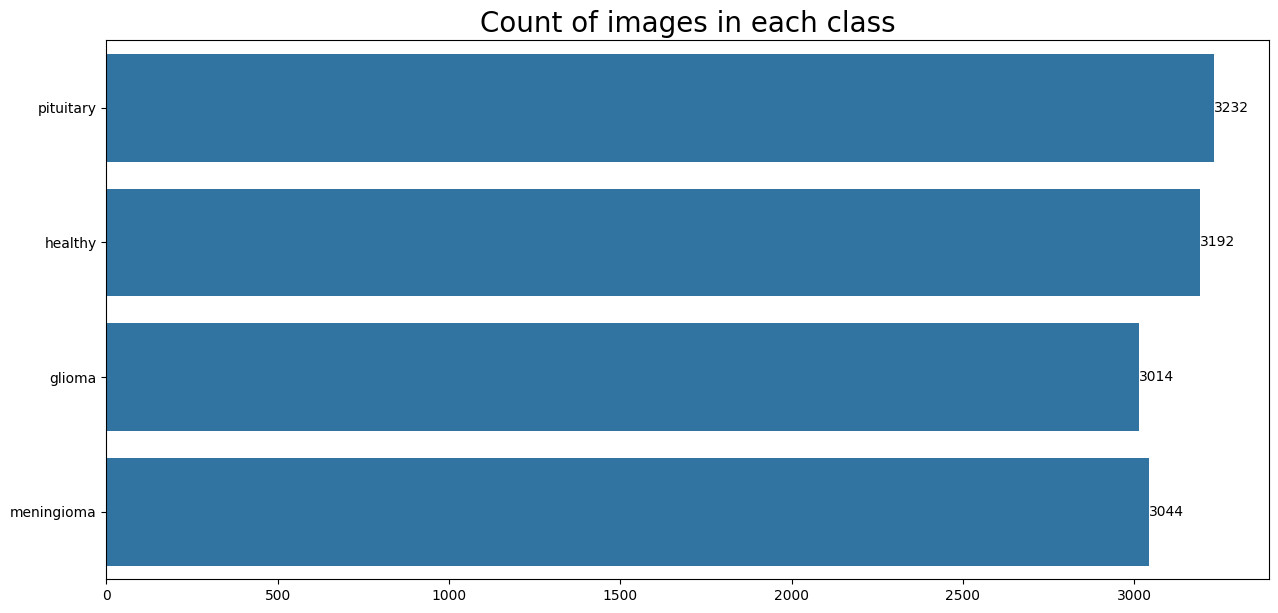

In [11]:
# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
save_path = os.path.join(save_dir, 'train_distribution.png')
plt.savefig(save_path, dpi=70, bbox_inches='tight')
plt.show()

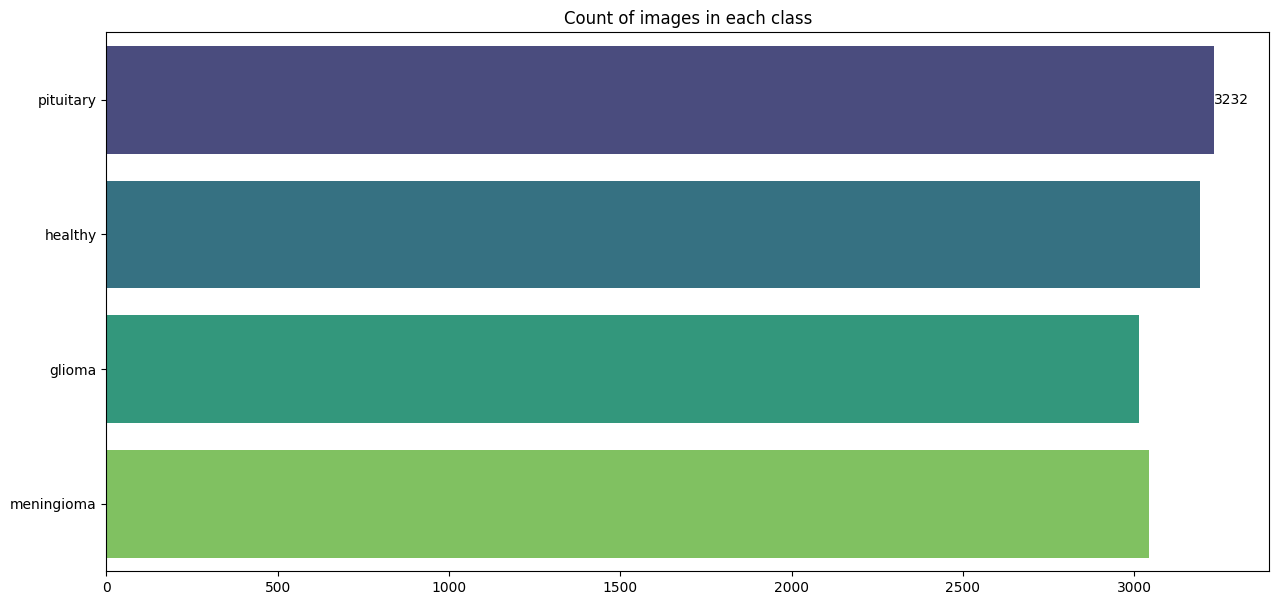

In [12]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])
save_path = os.path.join(save_dir, 'test_distribution.png')
plt.savefig(save_path, dpi=70, bbox_inches='tight')
plt.show()

## 2.2 Split data into train, test, valid

In [13]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [14]:
valid_df

,Class Path,Class
6309,/kaggle/working/images/train/healthy/healthy_0...,healthy
1832,/kaggle/working/images/train/pituitary/pituita...,pituitary
143,/kaggle/working/images/train/pituitary/pituita...,pituitary
5916,/kaggle/working/images/train/healthy/healthy_1...,healthy
914,/kaggle/working/images/train/pituitary/pituita...,pituitary
...,...,...
10705,/kaggle/working/images/train/meningioma/mening...,meningioma
5861,/kaggle/working/images/train/healthy/healthy_0...,healthy
7535,/kaggle/working/images/train/glioma/glioma_208...,glioma
576,/kaggle/working/images/train/pituitary/pituita...,pituitary


## 2.3 Data preprocessing

In [15]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 12482 validated image filenames belonging to 4 classes.
Found 6241 validated image filenames belonging to 4 classes.
Found 6241 validated image filenames belonging to 4 classes.


## 2.4 Getting samples from data

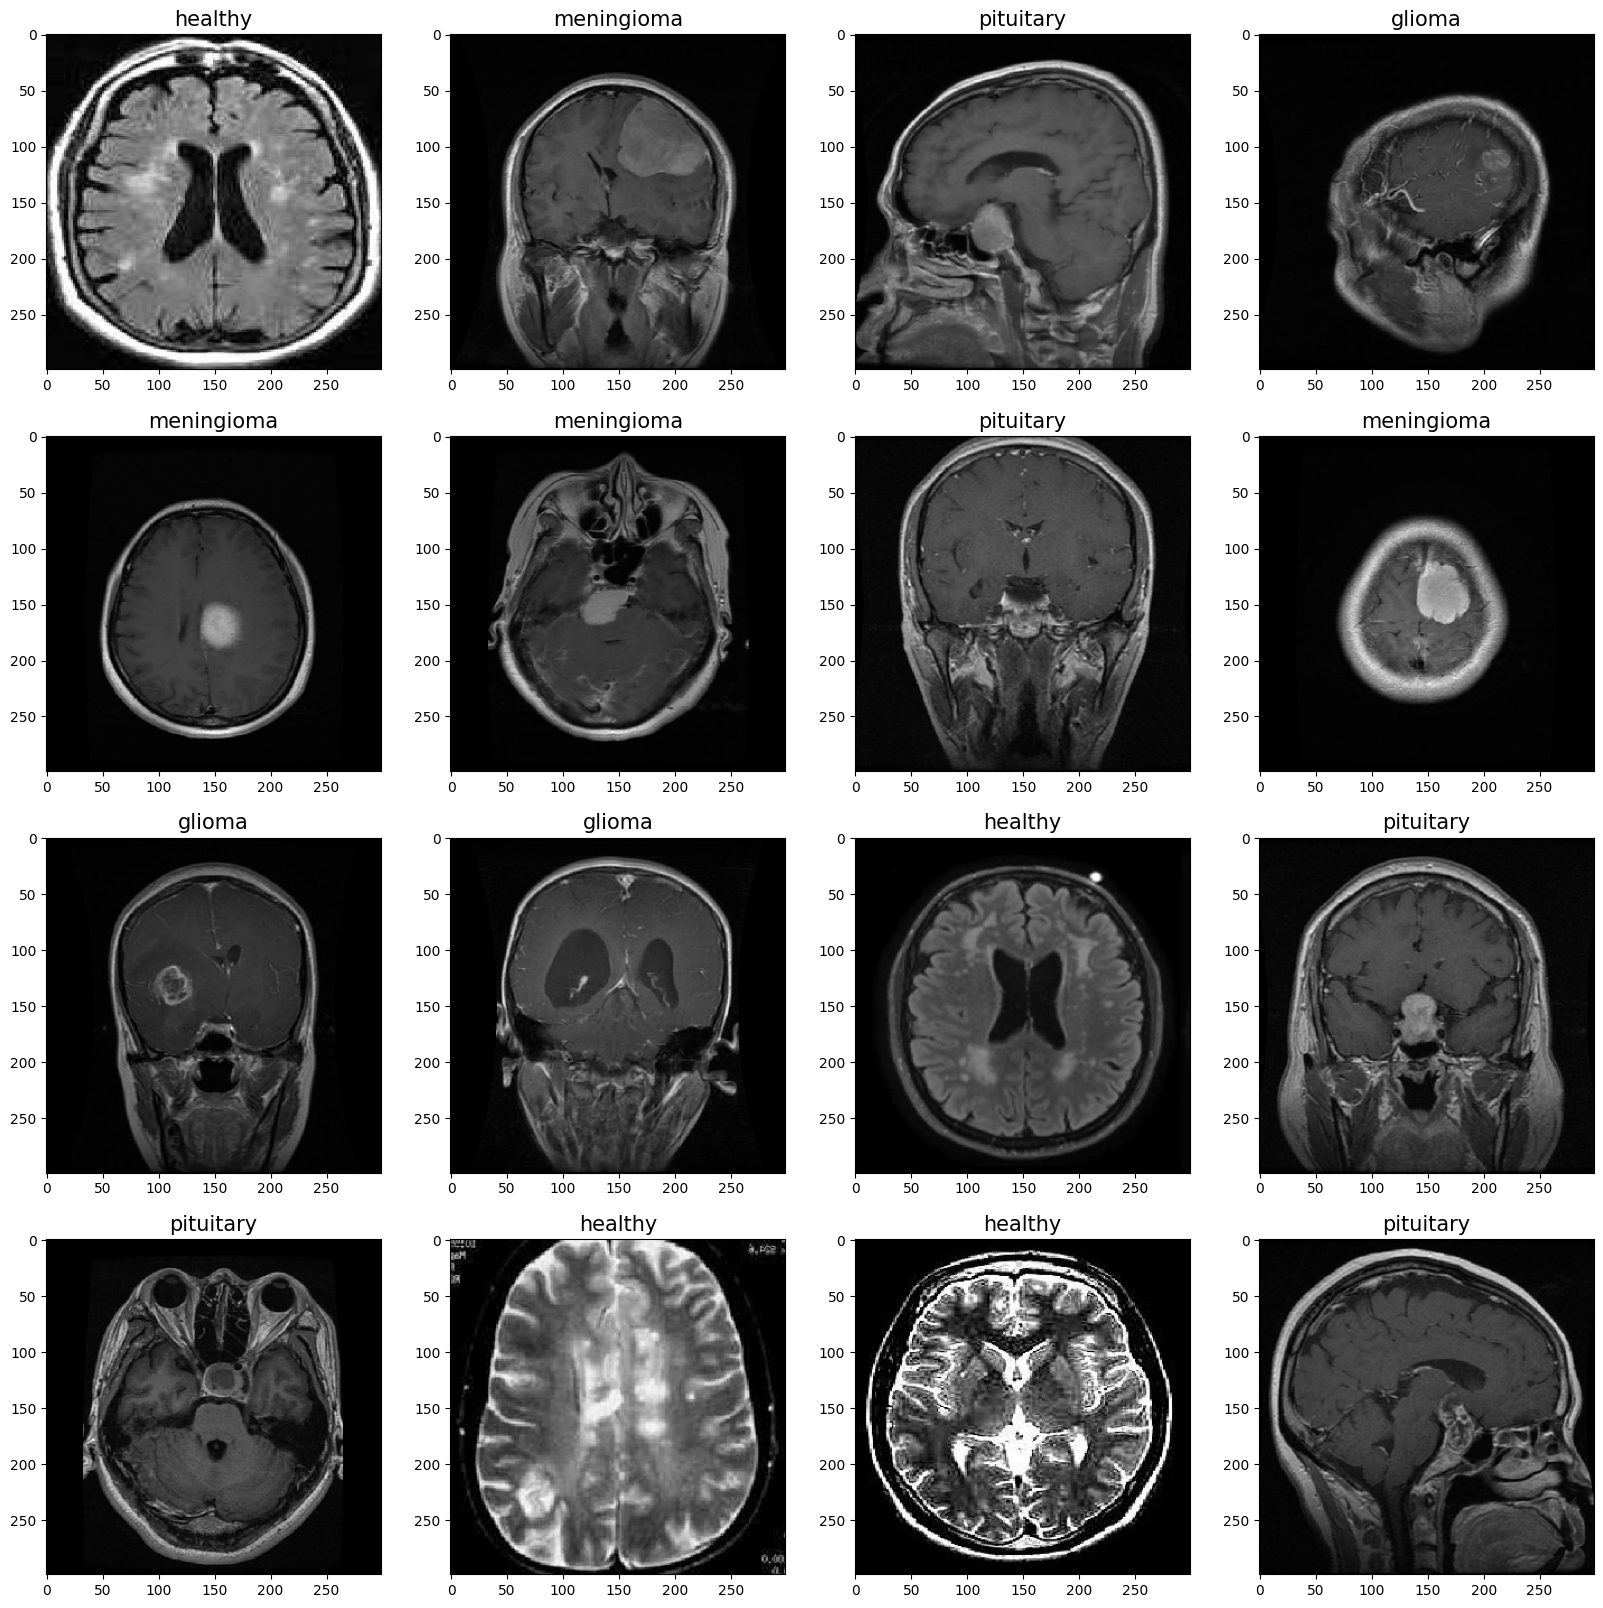

In [16]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

save_path = os.path.join(save_dir, 'sample_images.png')
plt.savefig(save_path, dpi=55, bbox_inches='tight')
plt.show()

# 3. Building Deep Learning Model

In [17]:
import tensorflow as tf
import numpy as np

# 1. Tự định nghĩa một Callback mới
class CustomCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, filepath):
        super(CustomCheckpoint, self).__init__()
        self.filepath = filepath
        self.best_loss = np.inf
        self.best_val_loss = np.inf

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get('loss')
        current_val_loss = logs.get('val_loss')

        if current_loss <= self.best_loss and current_val_loss <= self.best_val_loss:
            print(f'\n[SAVE] New Best Epoch {epoch + 1}. Saving model...')
            
            self.best_loss = current_loss
            self.best_val_loss = current_val_loss

            self.model.save(self.filepath)
        else:
            print(f'\n[SKIP] Epoch {epoch + 1} doesnt improved')

custom_checkpoint = CustomCheckpoint(filepath='best.h5')


log_csv = CSVLogger('training_log.csv', separator=',', append=False)

In [18]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

# for layer in base_model.layers:
#     layer.trainable = False
    
model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

I0000 00:00:1772947796.159062      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

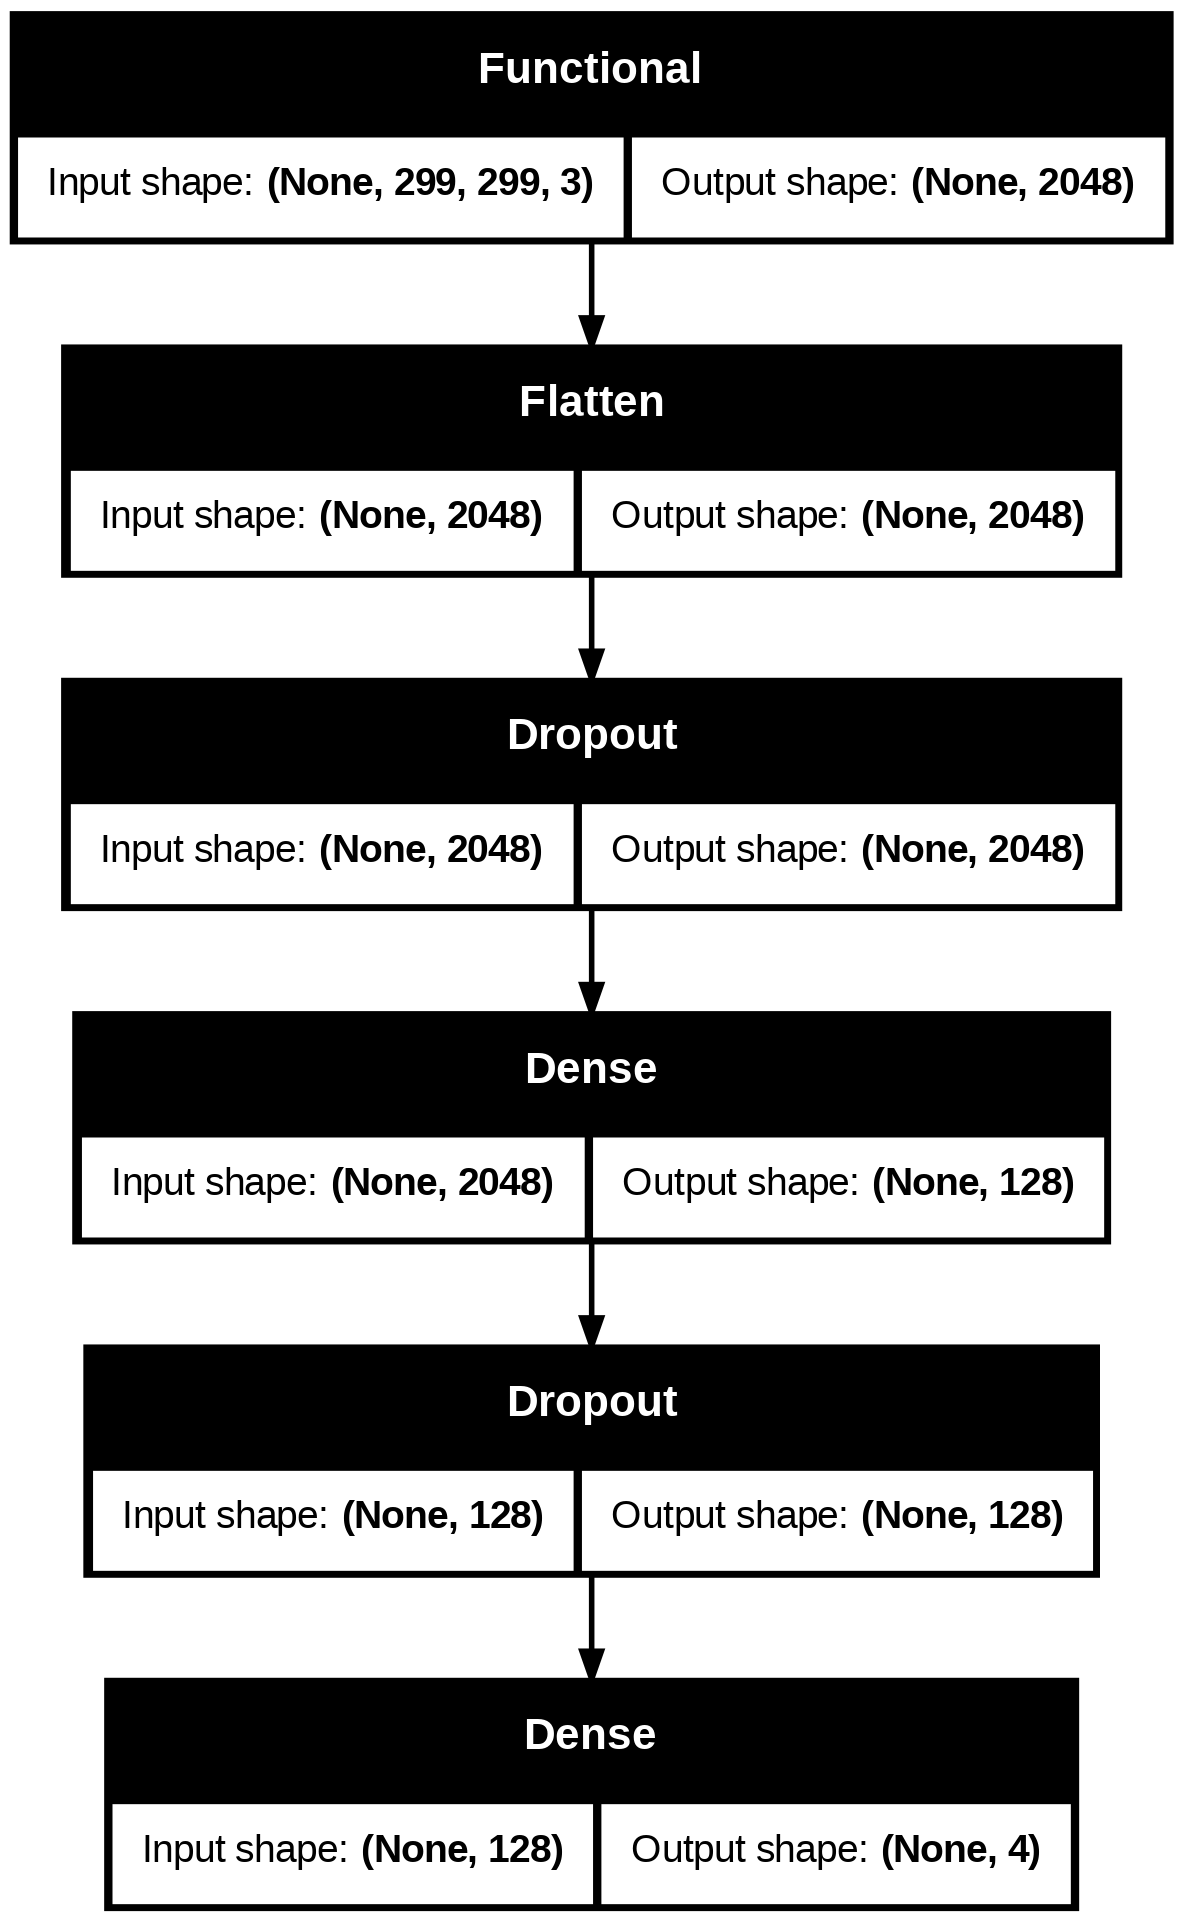

In [19]:
tf.keras.utils.plot_model(model, show_shapes=True)

# 4. Training

In [20]:
hist = model.fit(tr_gen,
                 epochs=15,
                 validation_data=valid_gen,
                 callbacks=[custom_checkpoint, log_csv],
                 shuffle= False)

Epoch 1/15


I0000 00:00:1772947818.818778      67 service.cc:152] XLA service 0x7e97c8004ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772947818.818821      67 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772947821.692044      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-08 05:30:41.381831: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 05:30:41.620801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 05:30:42.969204: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.7998 - loss: 0.5633 - precision: 0.8659 - recall: 0.6964


[SAVE] New Best Epoch 1. Saving model...
391/391 ━━━━━━━━━━━━━━━━━━━━ 331s 661ms/step - accuracy: 0.8001 - loss: 0.5625 - precision: 0.8661 - recall: 0.6968 - val_accuracy: 0.9721 - val_loss: 0.0721 - val_precision: 0.9725 - val_recall: 0.9707
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9885 - loss: 0.0323 - precision: 0.9890 - recall: 0.9884


[SAVE] New Best Epoch 2. Saving model...
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 522ms/step - accuracy: 0.9885 - loss: 0.0323 - precision: 0.9890 - recall: 0.9884 - val_accuracy: 0.9978 - val_loss: 0.0093 - val_precision: 0.9978 - val_recall: 0.9976
Epoch 3/15
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9947 - loss: 0.0182 - precision: 0.9955 - recall: 0.9944


[SAVE] New Best Epoch 3. Saving model...
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 521ms/step - accuracy: 0.9947 - loss: 0.0182 - precision: 0.9955 - recall: 0.9944 - val_accuracy: 0.9971 - val_loss: 0.0078 - val_precision: 0.9971 - val_recall: 0.9971
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9974 - loss: 0.0134 - precision: 0.9979 - recall: 0.9971


[SAVE] New Best Epoch 4. Saving model...
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 522ms/step - accuracy: 0.9974 - loss: 0.0134 - precision: 0.9979 - recall: 0.9971 - val_accuracy: 0.9998 - val_loss: 4.9154e-04 - val_precision: 0.9998 - val_recall: 0.9998
Epoch 5/15
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9986 - loss: 0.0043 - precision: 0.9986 - recall: 0.9984


[SAVE] New Best Epoch 5. Saving model...
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 522ms/step - accuracy: 0.9986 - loss: 0.0043 - precision: 0.9986 - recall: 0.9984 - val_accuracy: 1.0000 - val_loss: 1.8121e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 6/15
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9978 - loss: 0.0067 - precision: 0.9979 - recall: 0.9977
[SKIP] Epoch 6 doesnt improved
391/391 ━━━━━━━━━━━━━━━━━━━━ 203s 519ms/step - accuracy: 0.9978 - loss: 0.0067 - precision: 0.9979 - recall: 0.9977 - val_accuracy: 0.9997 - val_loss: 0.0014 - val_precision: 0.9997 - val_recall: 0.9997
Epoch 7/15
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9994 - loss: 0.0020 - precision: 0.9994 - recall: 0.9994
[SKIP] Epoch 7 doesnt improved
391/391 ━━━━━━━━━━━━━━━━━━━━ 203s 519ms/step - accuracy: 0.9994 - loss: 0.0020 - precision: 0.9994 - recall: 0.9994 - val_accuracy: 0.9995 - val_loss: 9.0755e-04 - val_precision: 0.9995 - val_recall: 0.9995
Epoch 8/15
390/391 ━━━━━━━━━━


[SAVE] New Best Epoch 13. Saving model...
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 522ms/step - accuracy: 0.9993 - loss: 0.0031 - precision: 0.9993 - recall: 0.9993 - val_accuracy: 1.0000 - val_loss: 2.3769e-05 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 14/15
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9998 - loss: 4.7142e-04 - precision: 0.9998 - recall: 0.9998
[SKIP] Epoch 14 doesnt improved
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 522ms/step - accuracy: 0.9998 - loss: 4.7477e-04 - precision: 0.9998 - recall: 0.9998 - val_accuracy: 1.0000 - val_loss: 2.8141e-05 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 15/15
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9990 - loss: 0.0026 - precision: 0.9992 - recall: 0.9990
[SKIP] Epoch 15 doesnt improved
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 520ms/step - accuracy: 0.9990 - loss: 0.0026 - precision: 0.9992 - recall: 0.9990 - val_accuracy: 1.0000 - val_loss: 7.2267e-05 - val_precision: 1.0000 - val_recall: 1.0000


In [21]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

## 4.1 Visualize model performance

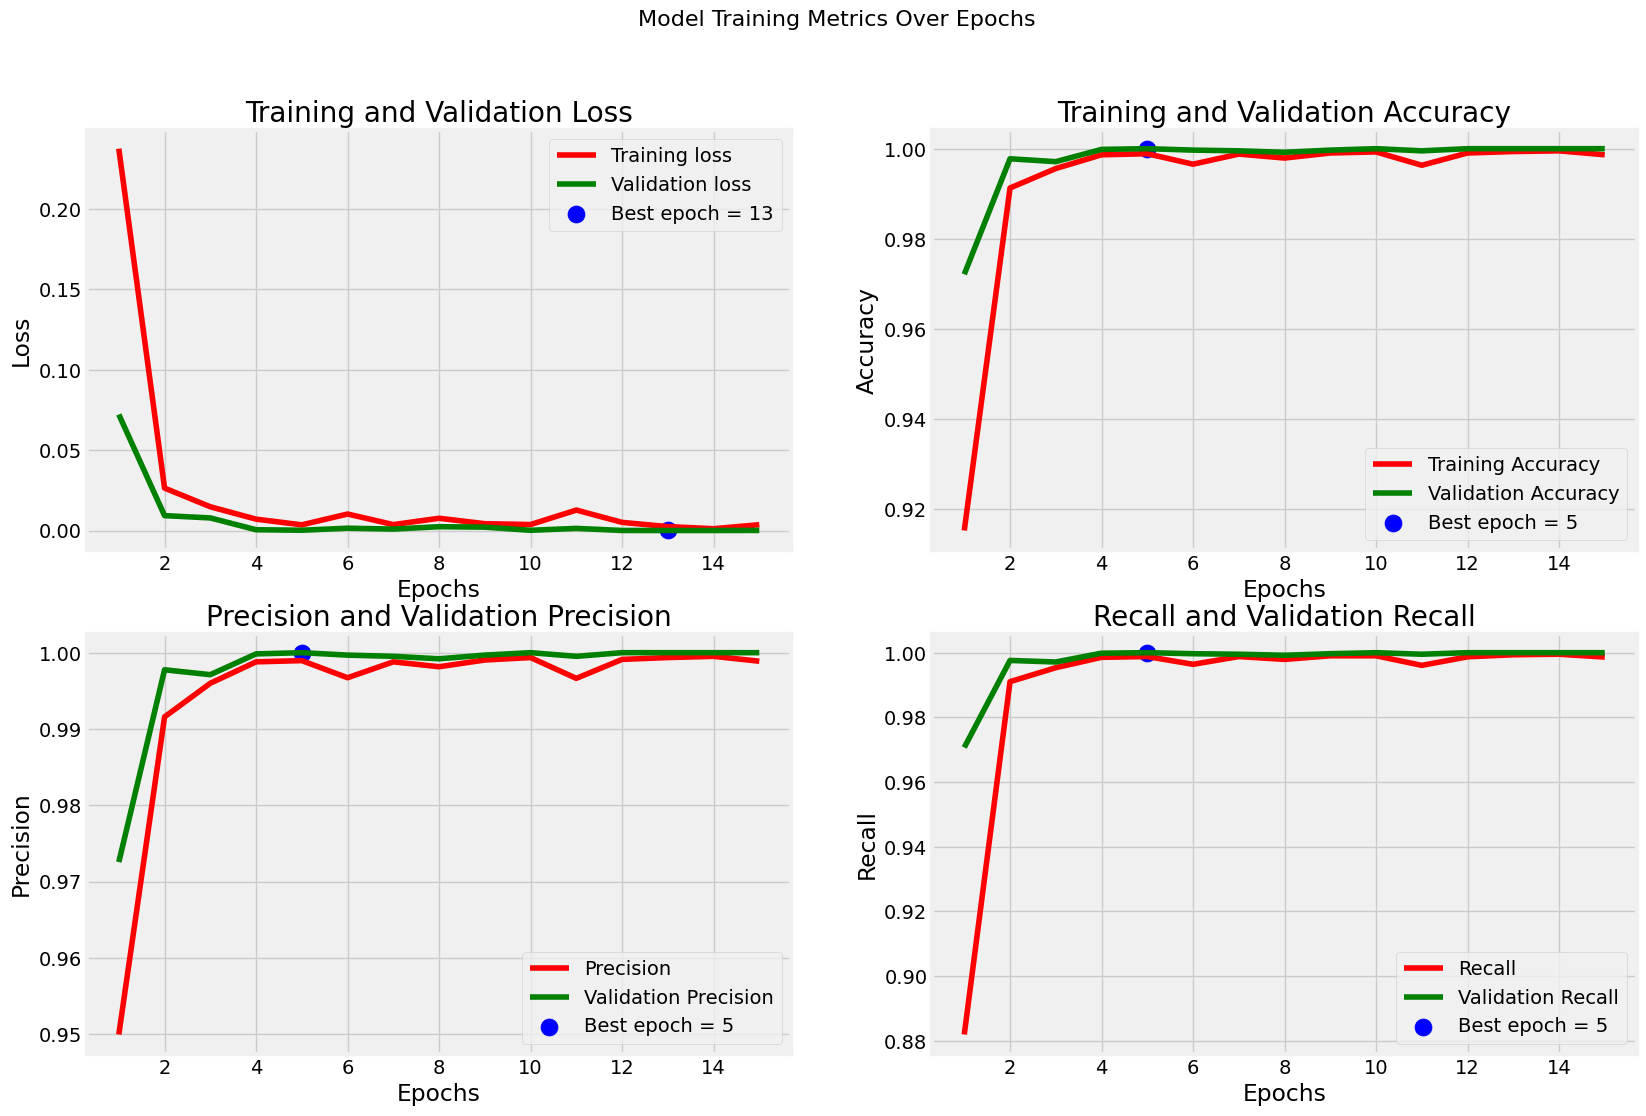

In [22]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
save_path = os.path.join(save_dir, 'train_metric_over_epochs.png')
plt.savefig(save_path, dpi=55, bbox_inches='tight')
plt.show()

# 5. Testing and Evaluation

## 5.1 Evaluate

In [23]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")


391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 1.0000 - loss: 9.9946e-05 - precision: 1.0000 - recall: 1.0000
196/196 ━━━━━━━━━━━━━━━━━━━━ 30s 152ms/step - accuracy: 1.0000 - loss: 7.0786e-05 - precision: 1.0000 - recall: 1.0000
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 1.0000 - loss: 5.6214e-05 - precision: 1.0000 - recall: 1.0000
Train Loss: 0.0001
Train Accuracy: 100.00%
--------------------
Validation Loss: 0.0001
Validation Accuracy: 100.00%
--------------------
Test Loss: 0.0001
Test Accuracy: 100.00%


In [24]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)

391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step


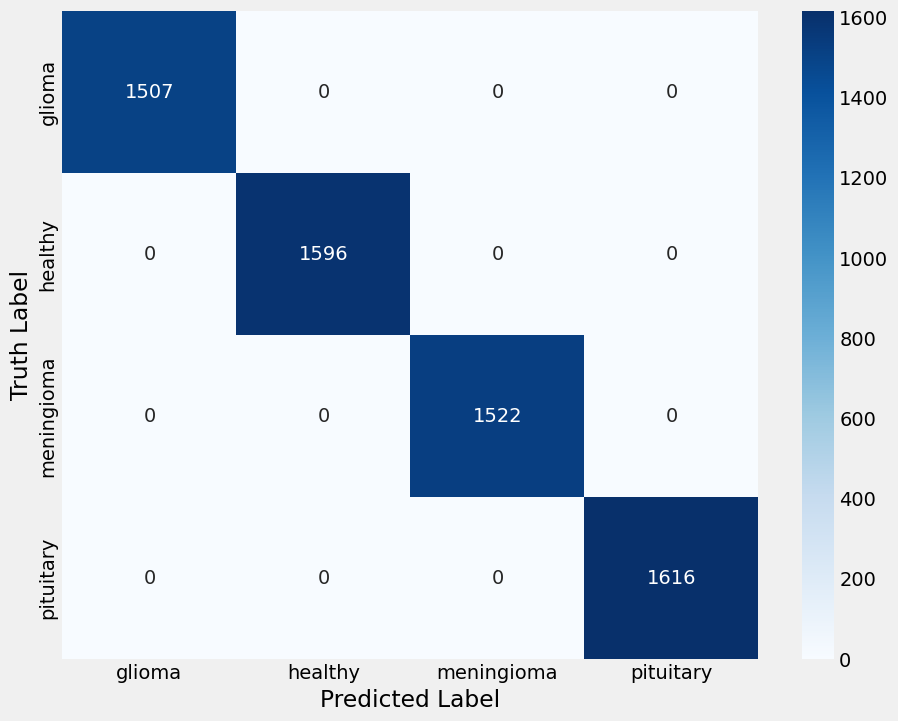

In [25]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
save_path = os.path.join(save_dir, 'test_confusion_matrix.png')
plt.savefig(save_path, dpi=105, bbox_inches='tight')
plt.show()

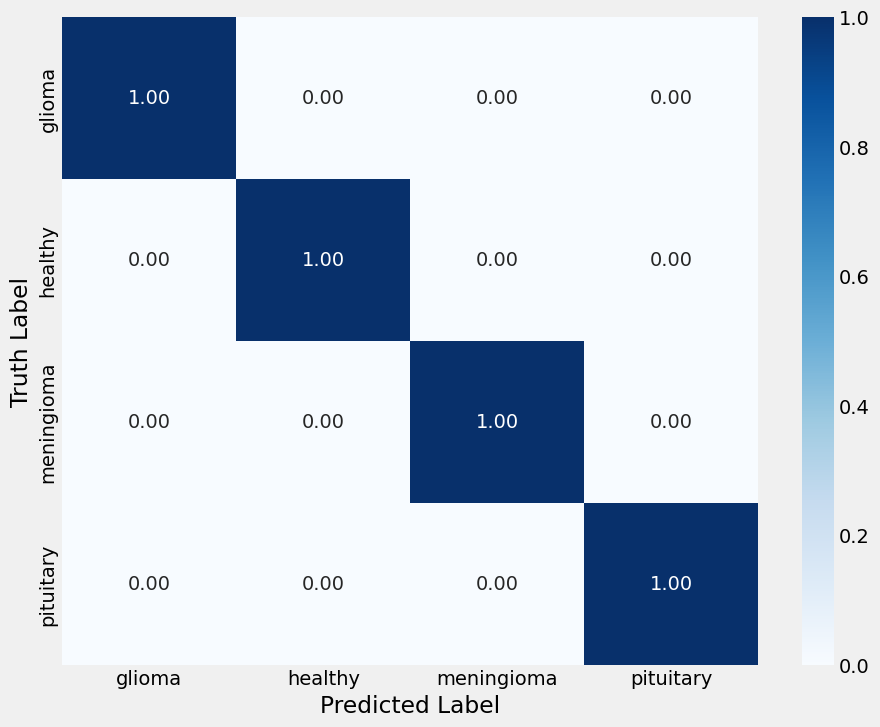

In [26]:
cm_nor = confusion_matrix(ts_gen.classes, y_pred, normalize = 'true')
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm_nor, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
save_path = os.path.join(save_dir, 'normalized_test_confusion_matrix.png')
plt.savefig(save_path, dpi=105, bbox_inches='tight')
plt.show()

In [27]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1507
           1       1.00      1.00      1.00      1596
           2       1.00      1.00      1.00      1522
           3       1.00      1.00      1.00      1616

    accuracy                           1.00      6241
   macro avg       1.00      1.00      1.00      6241
weighted avg       1.00      1.00      1.00      6241



## 5.2 Testing

In [28]:
def predict(img_path):
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    image_name = os.path.basename(image_path)
    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path)
    resized_img = img.resize((299, 299))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.title(f'{image_name}')
    save_path = os.path.join(save_dir, f'{image_name}.png')
    plt.savefig(save_path, dpi=85, bbox_inches='tight')
    plt.show()

In [29]:
import os
import random

def predict_random_images(folder_path, num_samples=5):
    all_images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    num_samples = min(num_samples, len(all_images))
    if num_samples == 0:
        print(f"Không tìm thấy ảnh nào trong {folder_path}!")
        return
    random_images = random.sample(all_images, num_samples)
    print(f"Đã bốc ngẫu nhiên {num_samples} ảnh. Đang tiến hành dự đoán...\n")
    for img_name in random_images:
        full_path = os.path.join(folder_path, img_name)
        predict(full_path)

# ================ MAIN =================
TARGET_FOLDER = '/kaggle/working/images/test'
predict_random_images(TARGET_FOLDER, num_samples=5)

Không tìm thấy ảnh nào trong /kaggle/working/images/test!
